# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Multi AMR Warehouse Dataset](https://www.kaggle.com/datasets/neurocipher/multi-amr-warehouse-eta-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('collected_datasets_combined-1.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,run_id,task_id,robot_id,start_zone,goal_zone,static_path_length_m,turn_count,junction_crossings_count,nominal_speed_mps,fleet_size,candidate_corridor_count,mean_nearby_robot_count,avg_nearby_robot_speed_mps,max_corridor_queue_length,reservation_count,corridor_occupancy_ratio,active_blockage_count,waiting_time_s,total_stop_time_s,mean_peer_freshness_ms,task_load_count,actual_travel_time_s
0,run_1789296146,rnd_task_001,robot_1,South,South,24.94,2,0,0.46,4,1,0.03,0.01,3,34,0.090,64,257.90,253.90,500.0,3,513.28
1,run_1789296146,rnd_task_002,robot_2,North,North,35.25,2,1,0.46,4,1,0.08,0.12,7,64,0.114,97,544.26,540.26,500.0,6,891.20
2,run_1789296146,rnd_task_003,robot_3,South,North,85.60,4,2,0.46,4,2,0.06,0.13,5,47,0.094,64,437.84,433.84,500.0,4,725.26
3,run_1789296146,rnd_task_004,robot_4,North,North,30.20,2,1,0.46,4,1,0.02,0.29,5,47,0.102,46,483.58,479.58,500.0,5,723.36
4,run_1789296146,rnd_task_005,robot_1,North,South,50.67,4,2,0.46,4,2,0.03,0.29,8,49,0.087,59,550.12,546.12,500.0,6,808.60


## last Five row

In [4]:
df.tail()

,run_id,task_id,robot_id,start_zone,goal_zone,static_path_length_m,turn_count,junction_crossings_count,nominal_speed_mps,fleet_size,candidate_corridor_count,mean_nearby_robot_count,avg_nearby_robot_speed_mps,max_corridor_queue_length,reservation_count,corridor_occupancy_ratio,active_blockage_count,waiting_time_s,total_stop_time_s,mean_peer_freshness_ms,task_load_count,actual_travel_time_s
16097,run_1789882692,rnd_task_014,robot_3,North,South,6.00,0,2,0.46,4,2,0.00,0.18,9,51,0.152,11,280.00,276.00,500.0,4,512.18
16098,run_1789882692,rnd_task_017,robot_4,North,North,30.73,2,1,0.46,4,1,0.00,0.18,4,24,0.127,3,164.66,160.66,500.0,1,283.10
16099,run_1789882692,rnd_task_019,robot_4,South,South,33.75,2,1,0.46,4,1,0.17,0.00,1,6,0.014,5,245.02,241.02,500.0,0,428.20
16100,run_1789882692,rnd_task_020,robot_4,North,Central,27.15,2,0,0.46,4,2,0.15,0.00,1,6,0.021,14,203.60,199.60,500.0,0,280.86
16101,run_1789882692,rnd_task_021,robot_4,North,North,18.47,2,1,0.46,4,1,0.00,0.18,1,6,0.033,7,97.40,93.40,500.0,0,180.40


## Shape of our dataset

In [5]:
df.shape

(16102, 22)

## List out all columns

In [6]:
df.columns

Index(['run_id', 'task_id', 'robot_id', 'start_zone', 'goal_zone',
       'static_path_length_m', 'turn_count', 'junction_crossings_count',
       'nominal_speed_mps', 'fleet_size', 'candidate_corridor_count',
       'mean_nearby_robot_count', 'avg_nearby_robot_speed_mps',
       'max_corridor_queue_length', 'reservation_count',
       'corridor_occupancy_ratio', 'active_blockage_count', 'waiting_time_s',
       'total_stop_time_s', 'mean_peer_freshness_ms', 'task_load_count',
       'actual_travel_time_s'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

run_id                         object
task_id                        object
robot_id                       object
start_zone                     object
goal_zone                      object
static_path_length_m          float64
turn_count                      int64
junction_crossings_count        int64
nominal_speed_mps             float64
fleet_size                      int64
candidate_corridor_count        int64
mean_nearby_robot_count       float64
avg_nearby_robot_speed_mps    float64
max_corridor_queue_length       int64
reservation_count               int64
corridor_occupancy_ratio      float64
active_blockage_count           int64
waiting_time_s                float64
total_stop_time_s             float64
mean_peer_freshness_ms        float64
task_load_count                 int64
actual_travel_time_s          float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16102 entries, 0 to 16101
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   run_id                      16102 non-null  object 
 1   task_id                     16102 non-null  object 
 2   robot_id                    16102 non-null  object 
 3   start_zone                  16102 non-null  object 
 4   goal_zone                   16102 non-null  object 
 5   static_path_length_m        16102 non-null  float64
 6   turn_count                  16102 non-null  int64  
 7   junction_crossings_count    16102 non-null  int64  
 8   nominal_speed_mps           16102 non-null  float64
 9   fleet_size                  16102 non-null  int64  
 10  candidate_corridor_count    16102 non-null  int64  
 11  mean_nearby_robot_count     16102 non-null  float64
 12  avg_nearby_robot_speed_mps  16102 non-null  float64
 13  max_corridor_queue_length   161

## Check Null Value

In [9]:
df.isnull().sum()

run_id                        0
task_id                       0
robot_id                      0
start_zone                    0
goal_zone                     0
static_path_length_m          0
turn_count                    0
junction_crossings_count      0
nominal_speed_mps             0
fleet_size                    0
candidate_corridor_count      0
mean_nearby_robot_count       0
avg_nearby_robot_speed_mps    0
max_corridor_queue_length     0
reservation_count             0
corridor_occupancy_ratio      0
active_blockage_count         0
waiting_time_s                0
total_stop_time_s             0
mean_peer_freshness_ms        0
task_load_count               0
actual_travel_time_s          0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,static_path_length_m,turn_count,junction_crossings_count,nominal_speed_mps,fleet_size,candidate_corridor_count,mean_nearby_robot_count,avg_nearby_robot_speed_mps,max_corridor_queue_length,reservation_count,corridor_occupancy_ratio,active_blockage_count,waiting_time_s,total_stop_time_s,mean_peer_freshness_ms,task_load_count,actual_travel_time_s
count,16102.000000,16102.000000,16102.000000,16102.00,16102.000000,16102.000000,16102.000000,16102.000000,16102.000000,16102.000000,16102.000000,16102.000000,16102.000000,16102.000000,16102.000000,16102.000000,16102.000000
mean,40.478434,2.308223,1.360017,0.46,3.999627,1.649671,0.052644,0.128673,6.316731,36.037076,0.105530,63.339896,247.903180,243.903180,499.950317,5.138741,574.585333
std,30.381852,1.512823,0.774331,0.00,0.033434,0.477088,0.073244,0.106861,2.102620,13.600105,0.044928,135.263480,201.063343,201.063343,4.457810,1.653405,305.600331
min,0.460000,0.000000,0.000000,0.46,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,12.620000,8.620000,100.000000,0.000000,42.680000
25%,8.360000,2.000000,1.000000,0.46,4.000000,1.000000,0.000000,0.040000,5.000000,27.000000,0.074000,9.000000,126.240000,122.240000,500.000000,4.000000,366.570000
50%,38.490000,2.000000,2.000000,0.46,4.000000,2.000000,0.030000,0.120000,6.000000,35.000000,0.094000,27.000000,199.760000,195.760000,500.000000,5.000000,523.100000
75%,65.990000,4.000000,2.000000,0.46,4.000000,2.000000,0.070000,0.180000,8.000000,43.000000,0.132000,73.000000,310.905000,306.905000,500.000000,6.000000,724.350000
max,117.940000,4.000000,2.000000,0.46,4.000000,2.000000,1.250000,0.460000,24.000000,164.000000,0.376000,3592.000000,3759.500000,3755.500000,500.000000,18.000000,5036.100000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

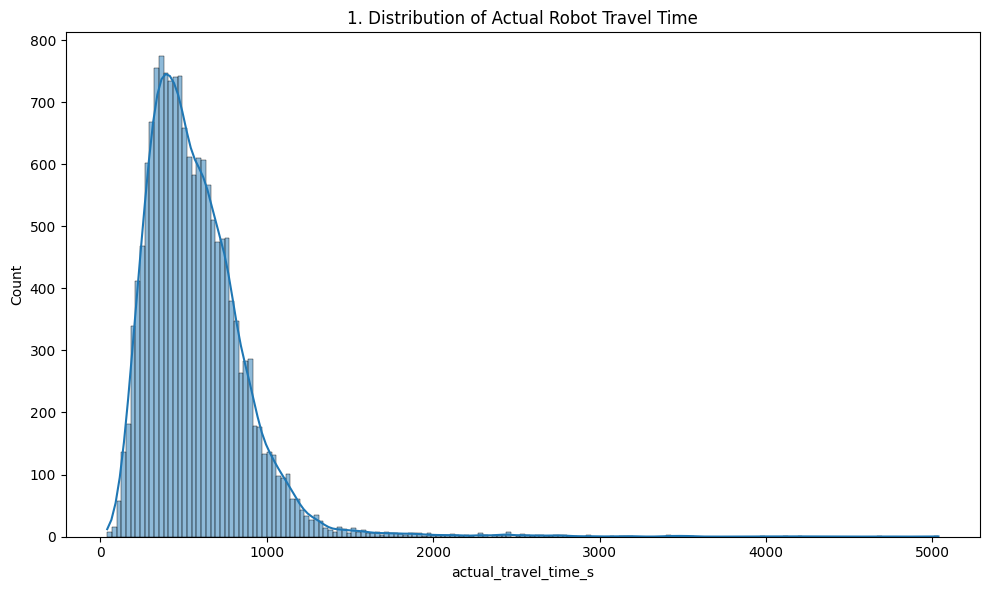

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='actual_travel_time_s', kde=True)
plt.title(f'{plot_no}. Distribution of Actual Robot Travel Time')
show_fig()
plot_no += 1

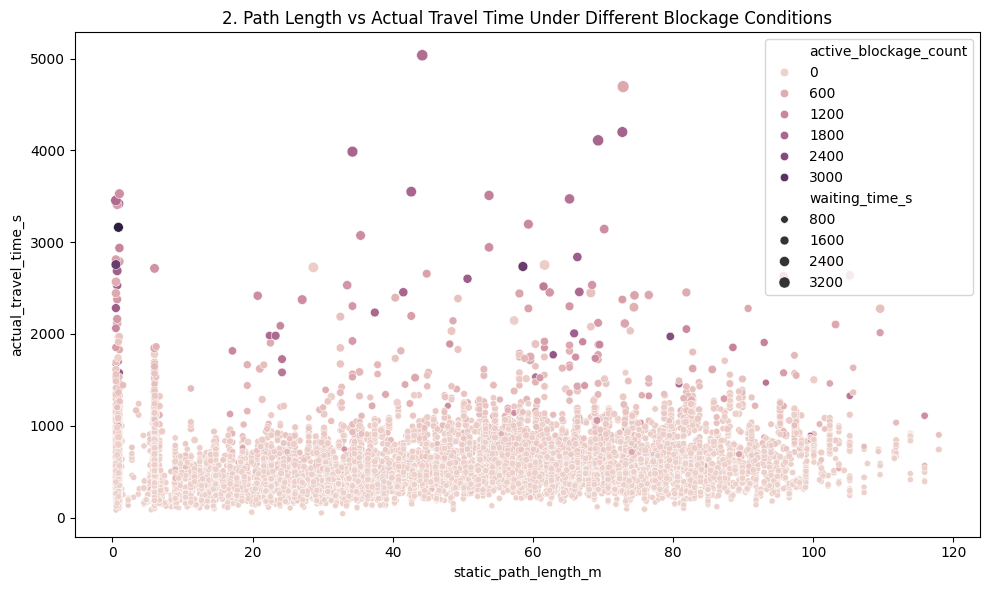

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='static_path_length_m', y='actual_travel_time_s', hue='active_blockage_count', size='waiting_time_s')
plt.title(f'{plot_no}. Path Length vs Actual Travel Time Under Different Blockage Conditions')
show_fig()
plot_no += 1

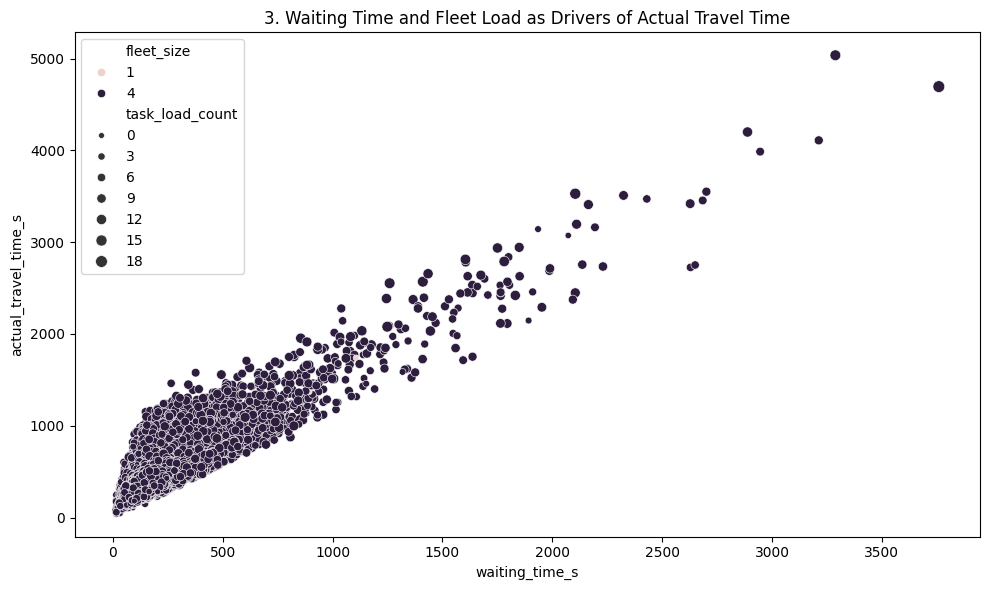

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='waiting_time_s', y='actual_travel_time_s', hue='fleet_size', size='task_load_count')
plt.title(f'{plot_no}. Waiting Time and Fleet Load as Drivers of Actual Travel Time')
show_fig()
plot_no += 1

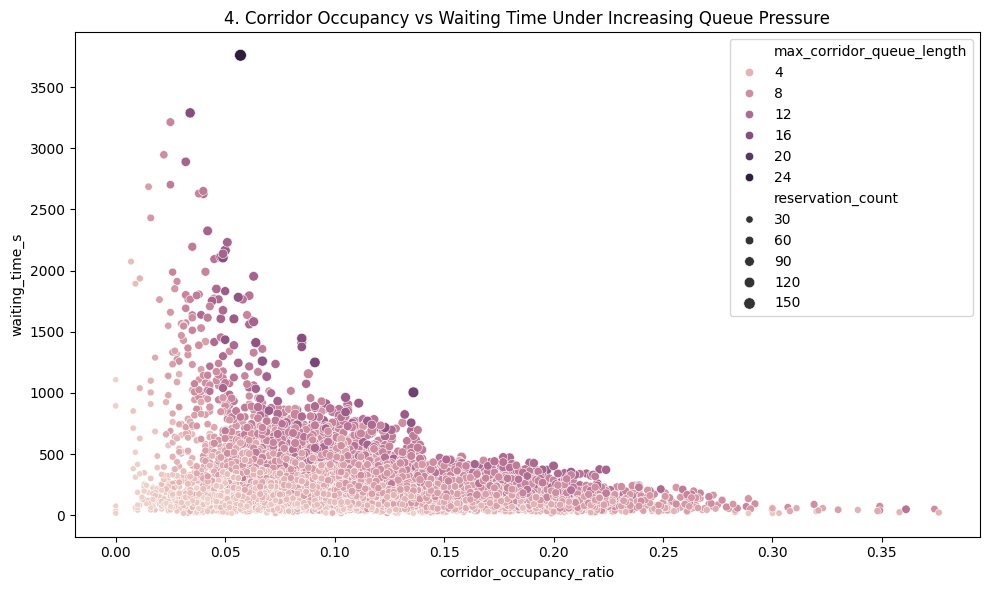

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='corridor_occupancy_ratio', y='waiting_time_s', hue='max_corridor_queue_length', size='reservation_count')
plt.title(f'{plot_no}. Corridor Occupancy vs Waiting Time Under Increasing Queue Pressure')
show_fig()
plot_no += 1

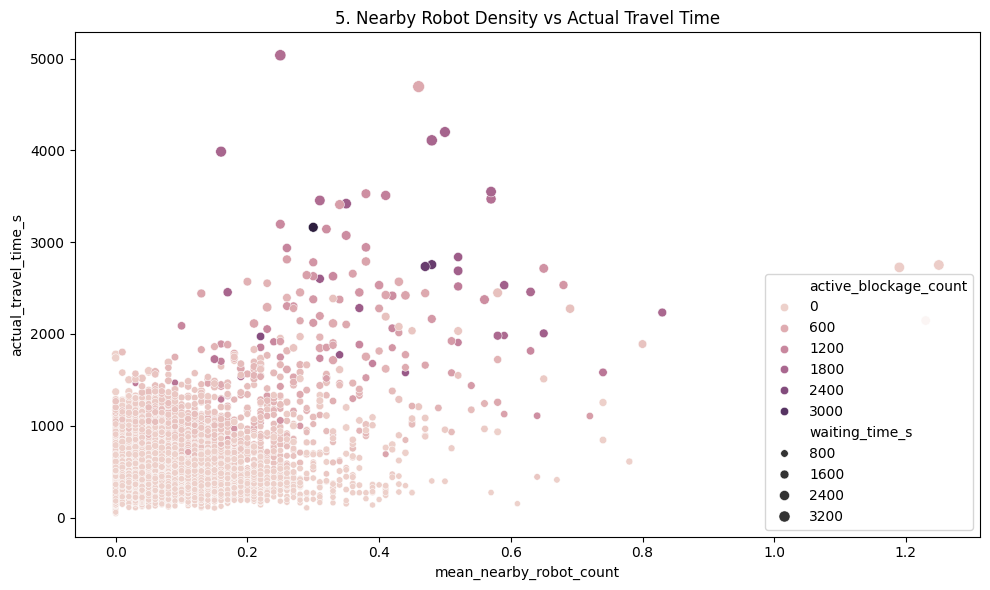

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='mean_nearby_robot_count', y='actual_travel_time_s', hue='active_blockage_count', size='waiting_time_s')
plt.title(f'{plot_no}. Nearby Robot Density vs Actual Travel Time')
show_fig()
plot_no += 1

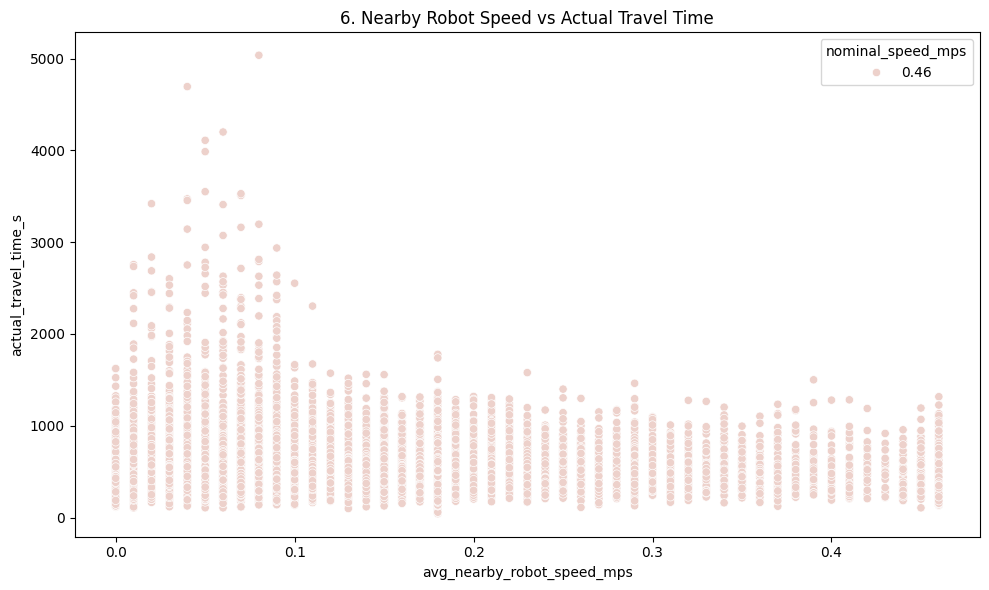

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='avg_nearby_robot_speed_mps', y='actual_travel_time_s', hue='nominal_speed_mps')
plt.title(f'{plot_no}. Nearby Robot Speed vs Actual Travel Time')
show_fig()
plot_no += 1

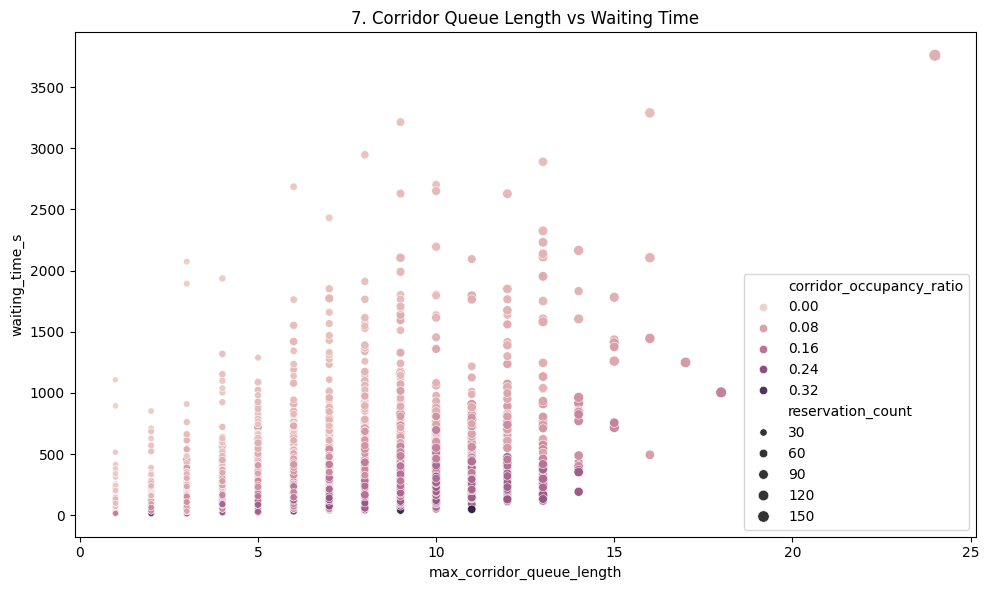

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='max_corridor_queue_length', y='waiting_time_s', hue='corridor_occupancy_ratio', size='reservation_count')
plt.title(f'{plot_no}. Corridor Queue Length vs Waiting Time')
show_fig()
plot_no += 1

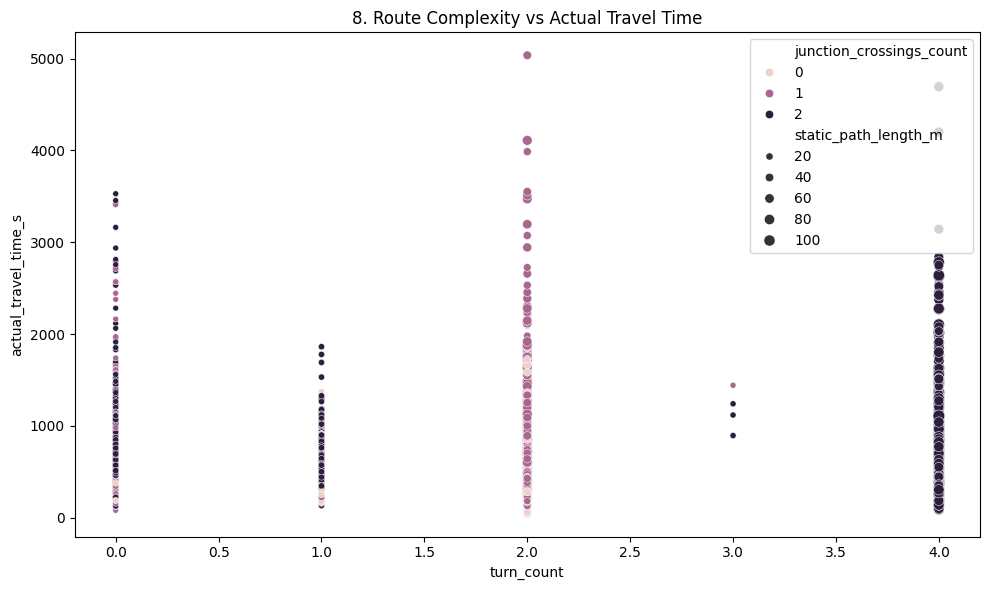

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='turn_count', y='actual_travel_time_s', hue='junction_crossings_count', size='static_path_length_m')
plt.title(f'{plot_no}. Route Complexity vs Actual Travel Time')
show_fig()
plot_no += 1

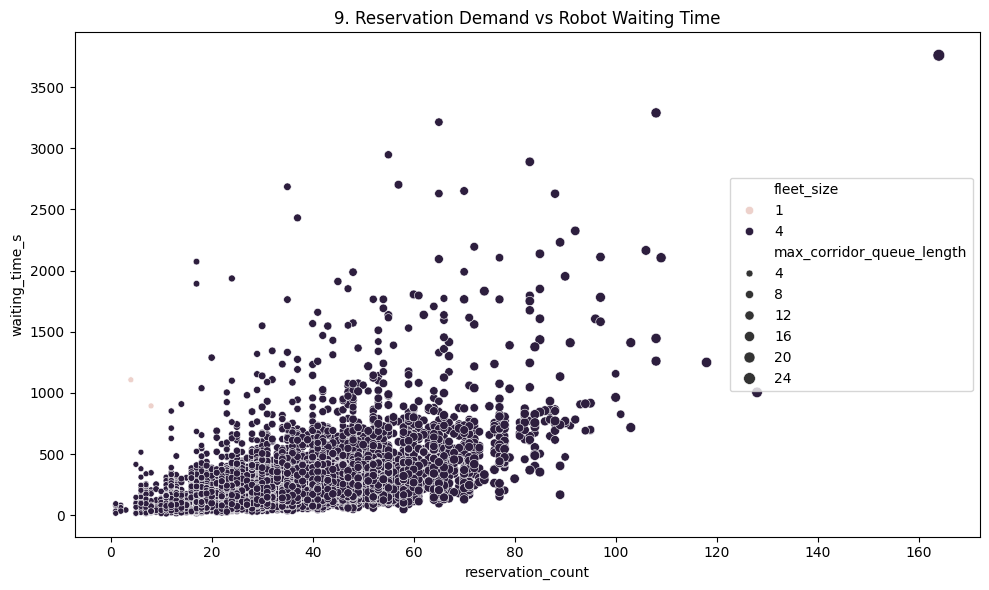

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='reservation_count', y='waiting_time_s', hue='fleet_size', size='max_corridor_queue_length')
plt.title(f'{plot_no}. Reservation Demand vs Robot Waiting Time')
show_fig()
plot_no += 1

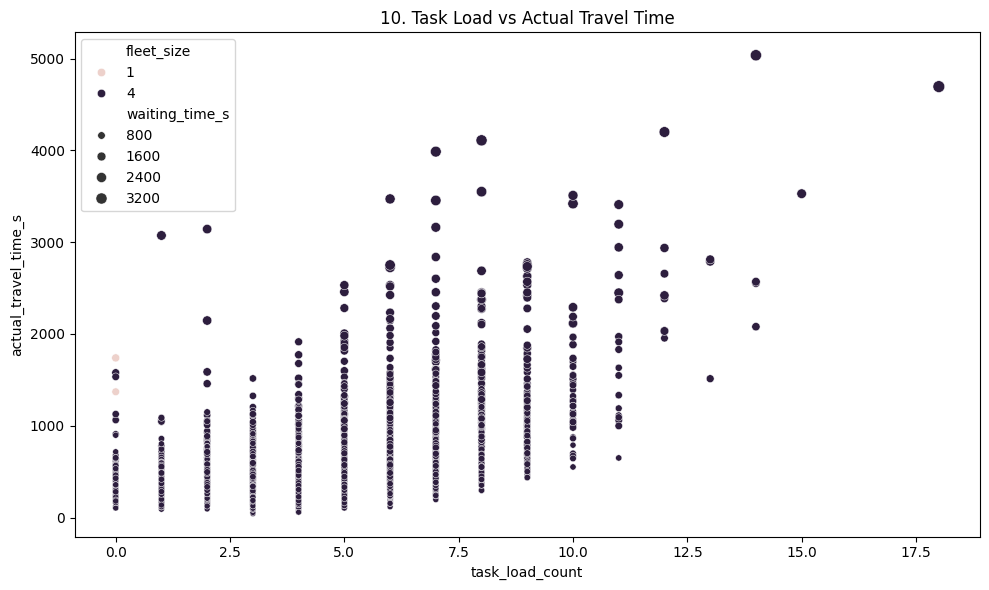

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='task_load_count', y='actual_travel_time_s', hue='fleet_size', size='waiting_time_s')
plt.title(f'{plot_no}. Task Load vs Actual Travel Time')
show_fig()
plot_no += 1

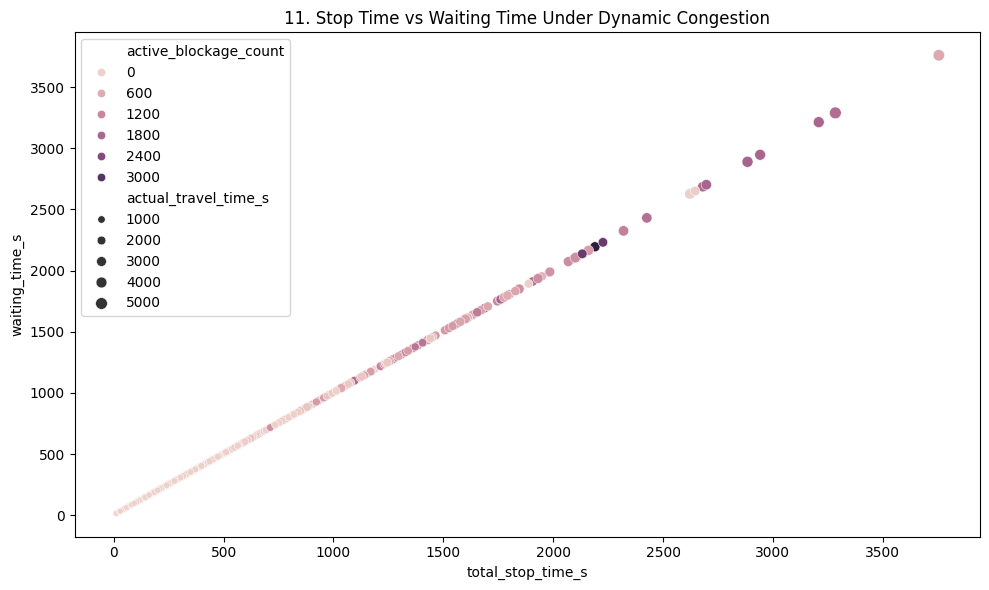

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='total_stop_time_s', y='waiting_time_s', hue='active_blockage_count', size='actual_travel_time_s')
plt.title(f'{plot_no}. Stop Time vs Waiting Time Under Dynamic Congestion')
show_fig()
plot_no += 1

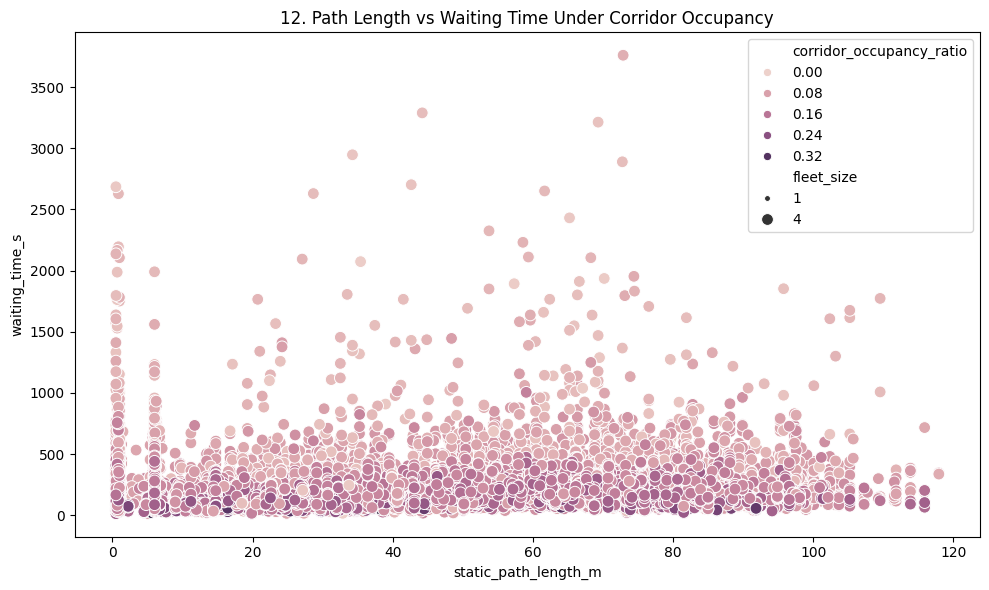

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='static_path_length_m', y='waiting_time_s', hue='corridor_occupancy_ratio', size='fleet_size')
plt.title(f'{plot_no}. Path Length vs Waiting Time Under Corridor Occupancy')
show_fig()
plot_no += 1

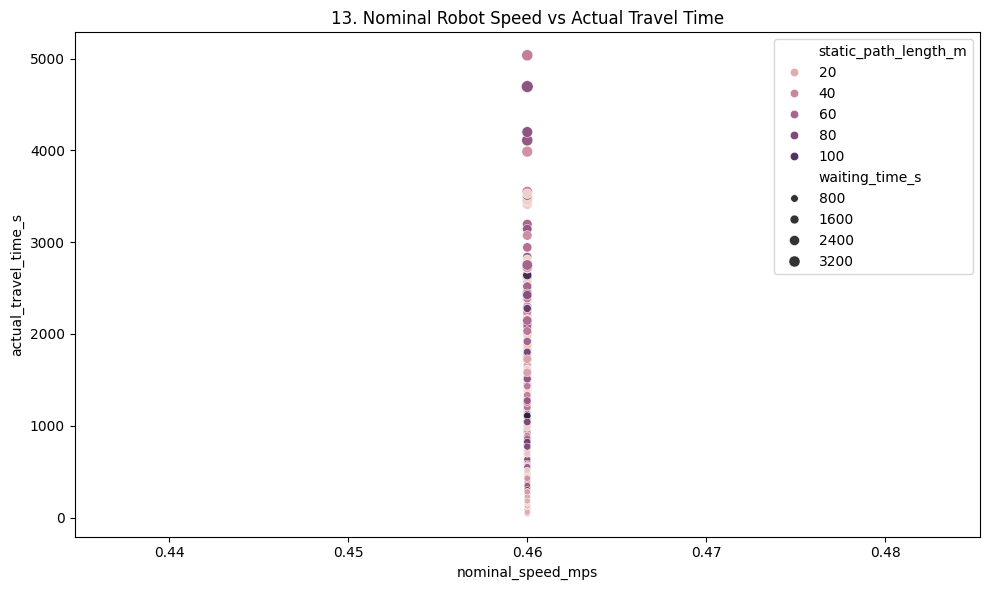

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='nominal_speed_mps', y='actual_travel_time_s', hue='static_path_length_m', size='waiting_time_s')
plt.title(f'{plot_no}. Nominal Robot Speed vs Actual Travel Time')
show_fig()
plot_no += 1

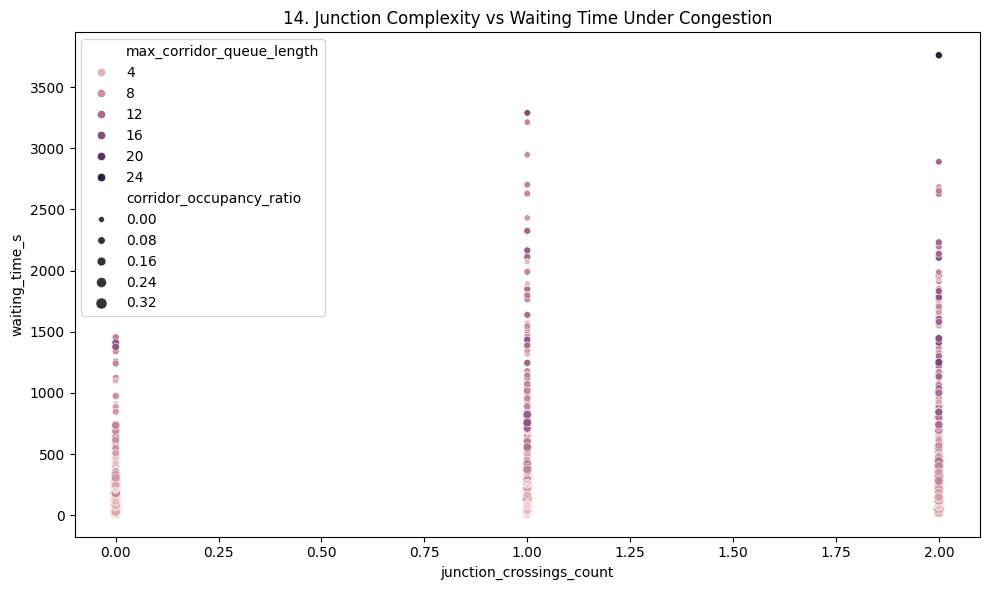

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='junction_crossings_count', y='waiting_time_s', hue='max_corridor_queue_length', size='corridor_occupancy_ratio')
plt.title(f'{plot_no}. Junction Complexity vs Waiting Time Under Congestion')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

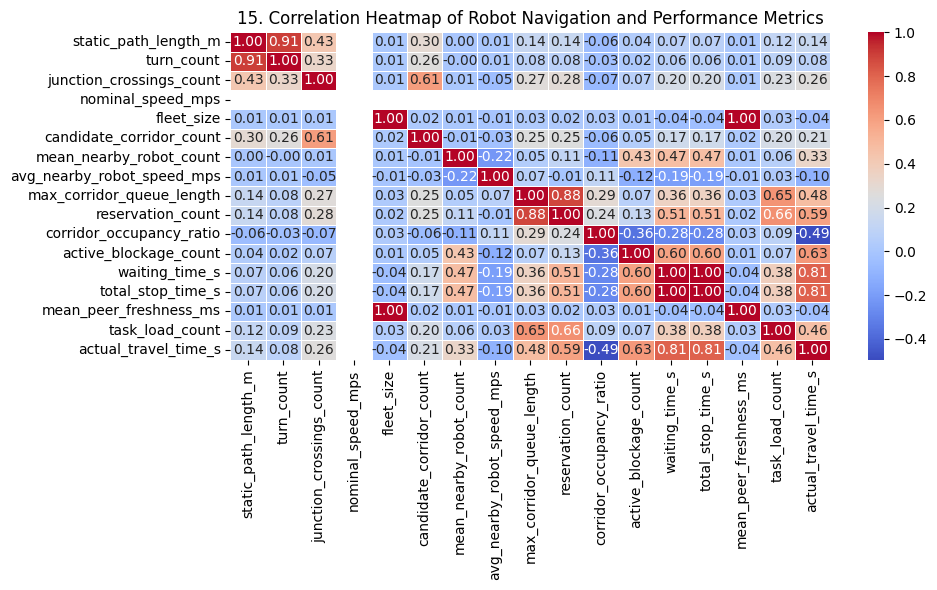

In [27]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Robot Navigation and Performance Metrics')
show_fig()
plot_no += 1

# Model Training

## Select numeric features and separate the target

In [28]:
X = df.select_dtypes(include='number').drop(
    columns=['actual_travel_time_s', 'nominal_speed_mps'],
    errors='ignore'
)
y = df['actual_travel_time_s']

## Split the dataset into training and testing sets

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Build an imputation, scaling, and SVR pipeline

In [30]:
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=100, epsilon=0.1))
])

## Train the model

In [31]:
model.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


## Generate predictions on the test data

In [32]:
y_pred = model.predict(X_test)

## Calculate model performance metrics

In [33]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"Model Accuracy (R² Score): {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

Model Accuracy (R² Score): 0.8196
MAE: 29.7346
RMSE: 133.1552


## Plot actual versus predicted travel time

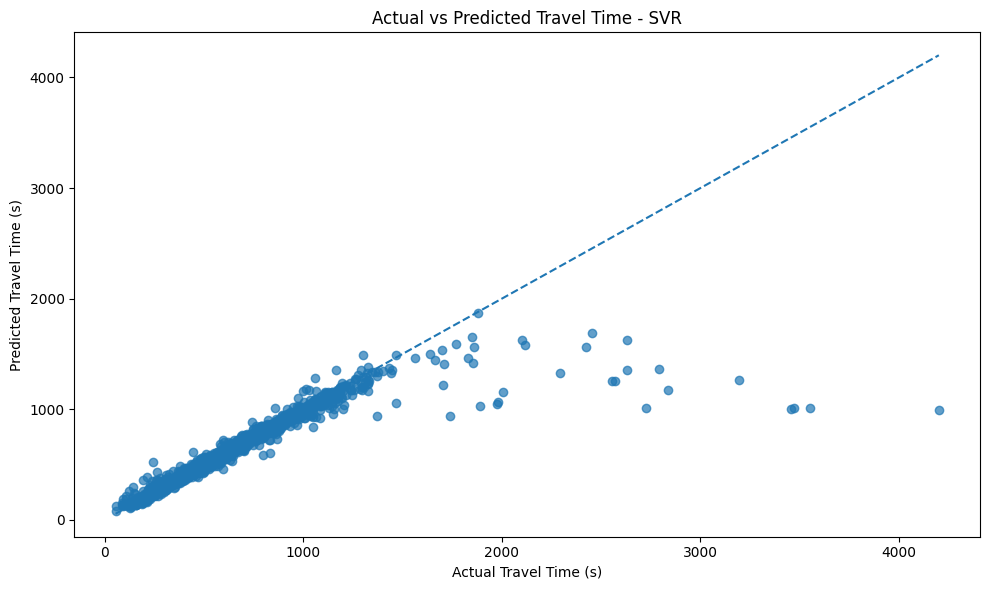

In [34]:
fig = plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel('Actual Travel Time (s)')
plt.ylabel('Predicted Travel Time (s)')
plt.title('Actual vs Predicted Travel Time - SVR')
show_fig()